# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [4]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])
x_train, x_test = x_train / 255., x_test / 255.

train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [5]:
class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.initializers.GlorotUniform()(shape=[in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation == 1:
            return tf.nn.softmax(y)   # вихідний шар
        else:
            return tf.nn.relu(y)      # приховані шари

In [6]:
class NN(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.layer1 = DenseLayer(num_features, n_hidden_1)
        self.layer2 = DenseLayer(n_hidden_1, n_hidden_2)
        self.out = DenseLayer(n_hidden_2, num_classes)

    def __call__(self, x):
        x1 = self.layer1(x, activation=0)
        x2 = self.layer2(x1, activation=0)
        x3 = self.out(x2, activation=1)
        return x3

In [7]:
def cross_entropy(y_pred, y_true):
    y_true = tf.one_hot(y_true, depth=num_classes)
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred), axis=1))



In [8]:
def accuracy(y_pred, y_true):
    acc = tf.metrics.Accuracy()
    acc.update_state(y_true, tf.argmax(y_pred, axis=1))
    return acc.result()



In [9]:
neural_net = NN(name="mnist")

def train(neural_net, input_x, output_y):
    optimizer = tf.optimizers.Adam(learning_rate)

    with tf.GradientTape() as g:
        pred = neural_net(input_x)
        loss = cross_entropy(pred, output_y)

    trainable_variables = [neural_net.layer1.w, neural_net.layer1.b,
                           neural_net.layer2.w, neural_net.layer2.b,
                           neural_net.out.w, neural_net.out.b]

    gradients = g.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss




In [10]:
loss_history = []
accuracy_history = []

for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    loss = train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)
        acc = accuracy(pred, batch_y)

        loss_history.append(loss.numpy())
        accuracy_history.append(acc.numpy())

        test_pred = neural_net(x_test)
        test_acc = accuracy(test_pred, y_test)

        print(f"Step: {step}, Loss: {loss.numpy():.4f}, Train Acc: {acc.numpy():.4f}, Test Acc: {test_acc.numpy():.4f}")



Step: 100, Loss: 0.3492, Train Acc: 0.9336, Test Acc: 0.9062
Step: 200, Loss: 0.2022, Train Acc: 0.9531, Test Acc: 0.9282
Step: 300, Loss: 0.2487, Train Acc: 0.9570, Test Acc: 0.9485
Step: 400, Loss: 0.2167, Train Acc: 0.9688, Test Acc: 0.9527
Step: 500, Loss: 0.1273, Train Acc: 0.9766, Test Acc: 0.9514
Step: 600, Loss: 0.1135, Train Acc: 0.9805, Test Acc: 0.9590
Step: 700, Loss: 0.0457, Train Acc: 0.9922, Test Acc: 0.9662
Step: 800, Loss: 0.0972, Train Acc: 0.9883, Test Acc: 0.9685
Step: 900, Loss: 0.0853, Train Acc: 0.9922, Test Acc: 0.9680
Step: 1000, Loss: 0.0454, Train Acc: 0.9961, Test Acc: 0.9717
Step: 1100, Loss: 0.1191, Train Acc: 0.9883, Test Acc: 0.9708
Step: 1200, Loss: 0.0440, Train Acc: 1.0000, Test Acc: 0.9667
Step: 1300, Loss: 0.1276, Train Acc: 0.9844, Test Acc: 0.9710
Step: 1400, Loss: 0.0664, Train Acc: 0.9922, Test Acc: 0.9726
Step: 1500, Loss: 0.0483, Train Acc: 1.0000, Test Acc: 0.9712
Step: 1600, Loss: 0.0626, Train Acc: 0.9961, Test Acc: 0.9729
Step: 1700, Loss:

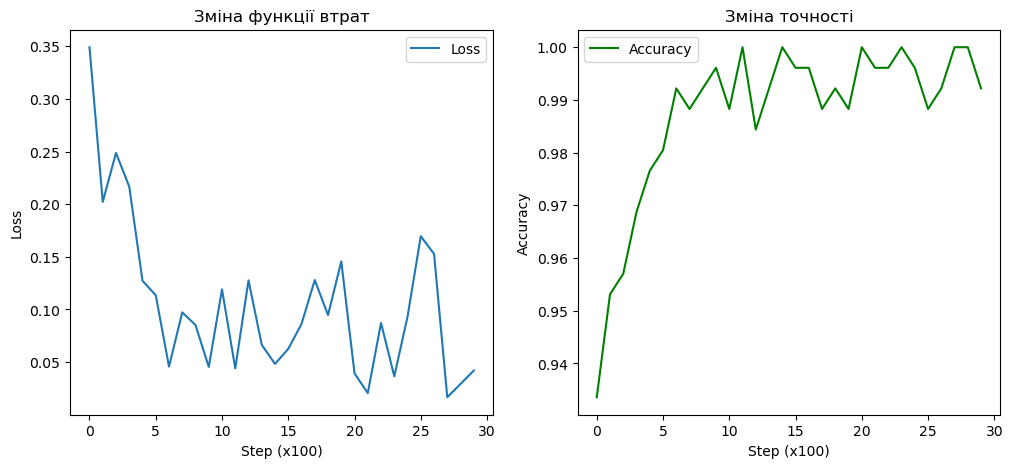

Train Accuracy: 0.9875
Test Accuracy: 0.9737
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.94      0.99      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.94      0.96       892
           6       0.99      0.97      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.94      0.98      0.96       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



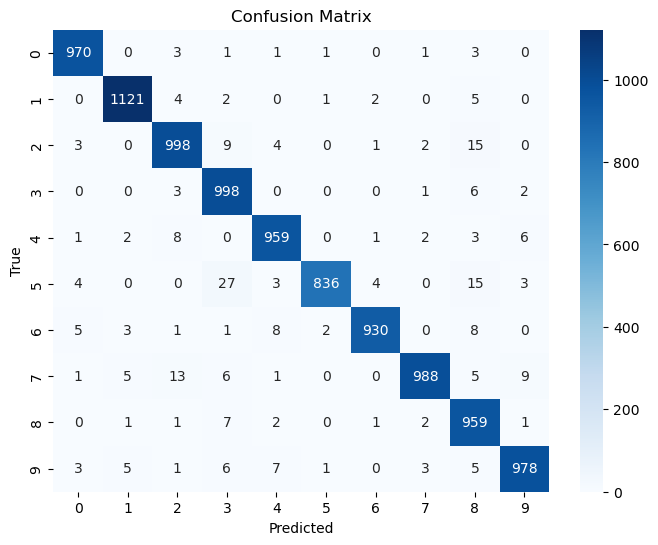

In [13]:
# Графіки
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(len(loss_history)), loss_history, label="Loss")
plt.xlabel("Step (x100)")
plt.ylabel("Loss")
plt.title("Зміна функції втрат")
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(len(accuracy_history)), accuracy_history, label="Accuracy", color="green")
plt.xlabel("Step (x100)")
plt.ylabel("Accuracy")
plt.title("Зміна точності")
plt.legend()
plt.show()

# Точність
pred_train = neural_net(x_train)
train_acc = accuracy(pred_train, y_train)
print(f"Train Accuracy: {train_acc.numpy():.4f}")

pred_test = neural_net(x_test)
test_acc = accuracy(pred_test, y_test)
print(f"Test Accuracy: {test_acc.numpy():.4f}")

# Звіт класифікації
y_pred_classes = tf.argmax(pred_test, axis=1)
target_names = [str(i) for i in range(num_classes)]
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# Матриця плутанини
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()







In [ ]:
Висновок:

середовище налаштоване,

дані оброблені,

модель побудована та навчена,

результати відповідають очікуваним для задачі класифікації MNIST